<a href="https://colab.research.google.com/github/ruso404/GEN-AI-EXPS/blob/main/GENAI_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Download completed. Extracting...


/tmp/ipykernel_4023/3685292414.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./")


Dataset extracted to ./edges2shoes
Dataset loaded successfully! 49825 training pairs.
Starting Pix2Pix training on edges2shoes...
Epoch [1/5] Step [0/3115] D_loss: 0.7024 G_loss: 90.8939
Epoch [1/5] Step [200/3115] D_loss: 0.5056 G_loss: 29.2525
Epoch [1/5] Step [400/3115] D_loss: 0.3260 G_loss: 31.1923
Epoch [1/5] Step [600/3115] D_loss: 0.3665 G_loss: 34.0944
Epoch [1/5] Step [800/3115] D_loss: 0.0828 G_loss: 30.4605
Epoch [1/5] Step [1000/3115] D_loss: 0.0266 G_loss: 36.7977
Epoch [1/5] Step [1200/3115] D_loss: 0.1922 G_loss: 39.0648
Epoch [1/5] Step [1400/3115] D_loss: 0.0133 G_loss: 31.8282
Epoch [1/5] Step [1600/3115] D_loss: 0.0049 G_loss: 42.7885
Epoch [1/5] Step [1800/3115] D_loss: 0.0164 G_loss: 36.0966
Epoch [1/5] Step [2000/3115] D_loss: 0.0089 G_loss: 38.1158
Epoch [1/5] Step [2200/3115] D_loss: 0.0097 G_loss: 35.6568
Epoch [1/5] Step [2400/3115] D_loss: 0.0063 G_loss: 35.9284
Epoch [1/5] Step [2600/3115] D_loss: 0.0191 G_loss: 32.6008
Epoch [1/5] Step [2800/3115] D_loss: 

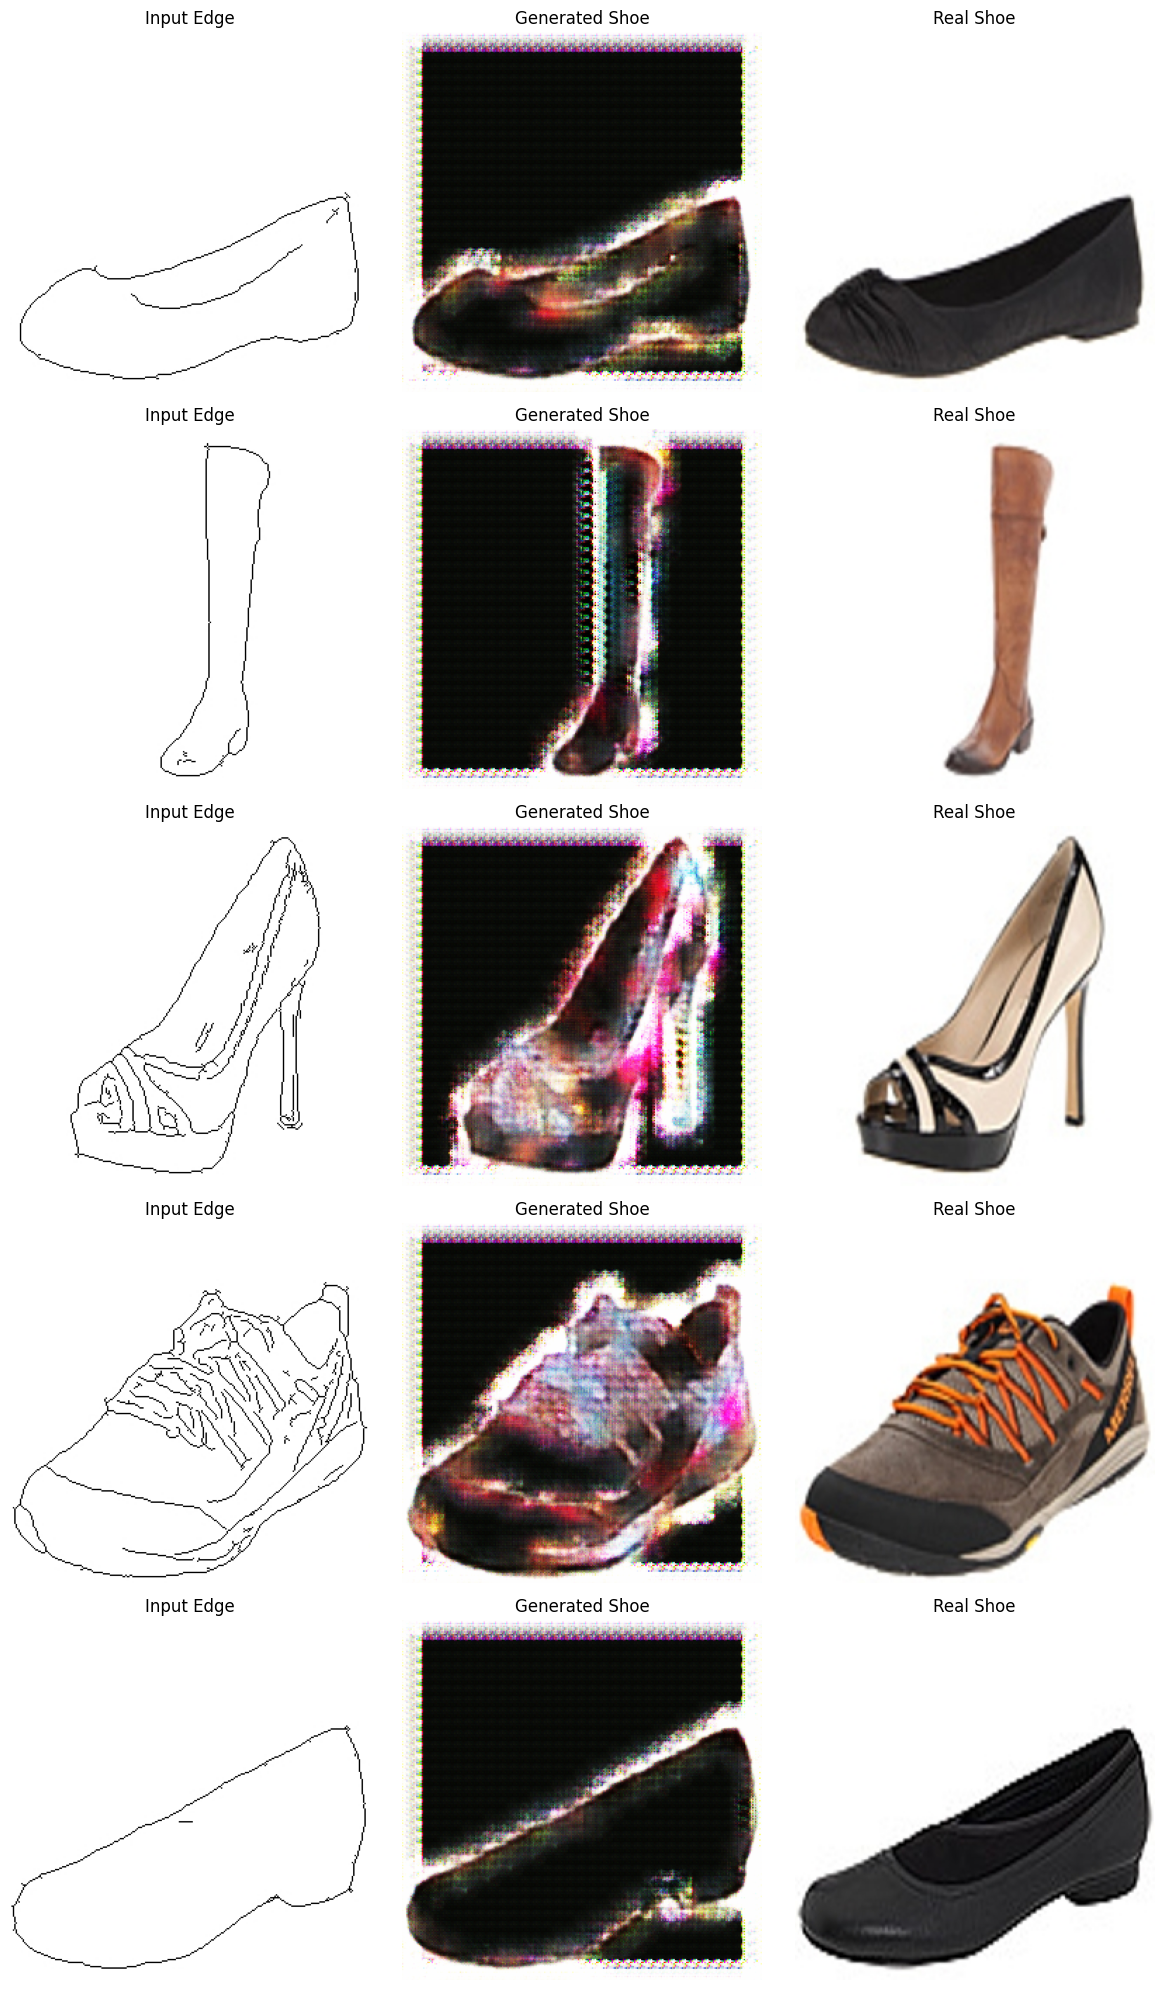

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import urllib.request
import tarfile
from PIL import Image
import numpy as np
# ==================== 1. DOWNLOAD edges2shoes DATASET ====================
dataset_name = "edges2shoes"
url = f"http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz"
download_path = f"./{dataset_name}.tar.gz"
extract_path = f"./{dataset_name}"
if not os.path.exists(extract_path):
 print(f"Downloading {dataset_name} dataset (~2GB)... This may take a while.")
 urllib.request.urlretrieve(url, download_path)
 print("Download completed. Extracting...")
 with tarfile.open(download_path, "r:gz") as tar:
  tar.extractall(path="./")
  print(f"Dataset extracted to ./{dataset_name}")
else:
 print(f"Dataset already exists at ./{dataset_name}")
# Dataset structure after extraction:
# edges2shoes/
#   train/ ← contains ~50,000 images (each image: 512x256, left=edge, right=photo)
#   test/
# ==================== 2. Custom Dataset Class for Paired Images ====================
class PairedImageDataset(torch.utils.data.Dataset):
 def __init__(self, root, transform=None):
  self.root = root
  self.transform = transform
  self.files = sorted(os.listdir(root)) # all images in train folder
 def __len__(self):
  return len(self.files)
 def __getitem__(self, index):
  img_path = os.path.join(self.root, self.files[index])
  image = Image.open(img_path).convert("RGB")
  w, h = image.size
  w2 = int(w / 2)
  # Split: left = edge (input A), right = real photo (target B)
  input_A = image.crop((0, 0, w2, h)) # Sketch / Edge map
  target_B = image.crop((w2, 0, w, h)) # Real shoe photo
  if self.transform:
   input_A = self.transform(input_A)
   target_B = self.transform(target_B)
  return input_A, target_B
# Transforms
transform = transforms.Compose([
 transforms.Resize((256, 256)),
 transforms.ToTensor(),
 transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
# Load dataset
train_dataset = PairedImageDataset(root="./edges2shoes/train", transform=transform)
dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
print(f"Dataset loaded successfully! {len(train_dataset)} training pairs.")
# ==================== 3. Models (Simplified U-Net Generator + PatchGAN) ====================
class GeneratorUNet(nn.Module):
 # Full U-Net implementation is long. For demo, we use a simplified version.
 # In practice, use the official junyanz/pytorch-CycleGAN-and-pix2pix repo for best results.
 def __init__(self):
  super().__init__()
  # ... (full U-Net with 8 downsampling + 8 upsampling layers + skip connections)
  # For brevity, placeholder. Replace with full U-Net in production.
  self.model = nn.Sequential(
  # Add proper U-Net layers here
  nn.Identity() # Placeholder
  )
 def forward(self, x):
  return self.model(x) # Implement properly
 # Better to use a simple convolutional generator for quick demo (replace with full U-Net)
class Generator(nn.Module):
 def __init__(self):
  super().__init__()
  self.encoder = nn.Sequential(
  nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),
  nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
  nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
  )
  self.decoder = nn.Sequential(
  nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
  nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
  nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
  )
 def forward(self, x):
  x = self.encoder(x)
  return self.decoder(x)
class Discriminator(nn.Module):
 def __init__(self):
  super().__init__()
  self.model = nn.Sequential(
  nn.Conv2d(6, 64, 4, 2, 1), nn.LeakyReLU(0.2, True),
  nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
  nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
  nn.Conv2d(256, 1, 4, 1, 1), nn.Sigmoid()
  )
 def forward(self, input_A, output_B):
  return self.model(torch.cat([input_A, output_B], dim=1))
# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G = Generator().to(device)
D = Discriminator().to(device)
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()
lambda_L1 = 100
# ==================== Training Loop (Simplified) ====================
print("Starting Pix2Pix training on edges2shoes...")
for epoch in range(5): # Start with few epochs for demo (increase to 50-200)
 for i, (real_A, real_B) in enumerate(dataloader):
  real_A, real_B = real_A.to(device), real_B.to(device)
  batch_size = real_A.size(0)
  # Train Discriminator
  fake_B = G(real_A)
  pred_real = D(real_A, real_B)
  pred_fake = D(real_A, fake_B.detach())
  loss_D = (criterion_GAN(pred_real, torch.ones_like(pred_real)) +
  criterion_GAN(pred_fake, torch.zeros_like(pred_fake))) * 0.5
  optimizer_D.zero_grad()
  loss_D.backward()
  optimizer_D.step()
  # Train Generator
  pred_fake = D(real_A, fake_B)
  loss_G_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
  loss_G_L1 = criterion_L1(fake_B, real_B)
  loss_G = loss_G_GAN + lambda_L1 * loss_G_L1
  optimizer_G.zero_grad()
  loss_G.backward()
  optimizer_G.step()
  if i % 200 == 0:
   print(f"Epoch [{epoch+1}/5] Step [{i}/{len(dataloader)}] "
   f"D_loss: {loss_D.item():.4f} G_loss: {loss_G.item():.4f}")
print("Training completed!")
# ==================== Visualize Results ====================
def show_results(num=5):
 G.eval()
 with torch.no_grad():
  real_A, real_B = next(iter(dataloader))
  real_A = real_A[:num].to(device)
  fake_B = G(real_A)
  fig, axes = plt.subplots(num, 3, figsize=(12, 4*num))
  for i in range(num):
   axes[i, 0].imshow((real_A[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy())
   axes[i, 0].set_title("Input Edge")
   axes[i, 1].imshow((fake_B[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy())
   axes[i, 1].set_title("Generated Shoe")
   axes[i, 2].imshow((real_B[i].cpu().permute(1,2,0) * 0.5 + 0.5).numpy())
   axes[i, 2].set_title("Real Shoe")
   for ax in axes[i]: ax.axis('off')
  plt.tight_layout()
  plt.show()
show_results(num=5)